# Notebook 06 — Material acceptability maps (F6, deterministic draft)

The forward model says what a given material would deliver. Inverting it asks the
question the literature almost never does: *what would a material have to be* for a
complete onboard system to meet the DOE targets? This notebook sweeps two material
parameters at a time, holds the rest at the AX-21 reference values, and shades the
region where the system clears both the gravimetric and the volumetric target.

All physics lives in the `h2star` package; this notebook loads, calls, prints and draws.

**This is the deterministic draft of the signature figure.** The boundary is drawn as
a sharp line here, and that sharpness is not defensible: Gate V2 established that the
modified Dubinin–Astakhov parameters are not recoverable from a single published
isotherm (`docs/validation_plan.md`), so a line implies a precision the parameter
estimates do not carry. The published F6 redraws the boundary as a Monte Carlo
probability band once the uncertainty layer passes Gate V4. Read this version as the
shape of the answer, not as its edge.

**And read the absolute position of the boundary as optimistic.** The Gate V3 FAIL
places the vessel, insulation and balance-of-plant mass block about 4.2x light, so the
real acceptable region is smaller than the one shaded below.

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np

from h2star import envelope, inverse, isotherm, system
from h2star.viz import plot_acceptability_maps

In [2]:
# Paths are written relative to the repository root: this notebook is meant to be
# executed with the repo root as the working directory. The fallback below also
# lets it run interactively from inside notebooks/.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").is_dir():
    REPO_ROOT = Path("..").resolve()

MATERIAL_YAML = REPO_ROOT / "data" / "materials" / "ax21.yaml"
ENGINEERING_YAML = REPO_ROOT / "data" / "engineering.yaml"
TARGETS_YAML = REPO_ROOT / "data" / "targets" / "doe_targets.yaml"

material = isotherm.Material.from_yaml(MATERIAL_YAML)
da = isotherm.ModifiedDA(material)
engineering = system.EngineeringParams.from_yaml(ENGINEERING_YAML)
targets = inverse.load_doe_targets(TARGETS_YAML, "2025")

print(f"material: {material.name}")
print(f"targets : {targets.label} - GC >= {targets.gc} kg/kg, "
      f"VC >= {targets.vc} kg/L")

material: AX-21
targets : DOE 2025 - GC >= 0.055 kg/kg, VC >= 0.04 kg/L


## Fix the operating envelope

The acceptability map varies the *material* at a fixed operating point, so the
envelope has to be stated explicitly rather than optimized per node — otherwise each
node would be a different tank design and the map would confound two effects. The
baseline 100 bar / 80 K full state with a 5 bar / 160 K discharge is used here.

In [3]:
operating_point = envelope.OperatingPoint(P_full=100.0e5, T_full=80.0)

print(f"full  : {operating_point.P_full / 1e5:.0f} bar / "
      f"{operating_point.T_full:.0f} K")
print(f"empty : {operating_point.P_empty / 1e5:.0f} bar / "
      f"{operating_point.T_empty:.0f} K")
print()
print("reference AX-21 parameters held fixed where not swept:")
print(f"  n_max    = {material.n_max} mol/kg")
print(f"  alpha    = {material.alpha} J/mol")
print(f"  beta     = {material.beta} J/(mol K)")
print(f"  v_a      = {material.v_a} m^3/kg")
print(f"  rho_bulk = {material.rho_bulk} kg/m^3")
print(f"  rho_skel = {material.rho_skel} kg/m^3")

full  : 100 bar / 80 K
empty : 5 bar / 160 K

reference AX-21 parameters held fixed where not swept:
  n_max    = 71.6 mol/kg
  alpha    = 3080 J/mol
  beta     = 18.9 J/(mol K)
  v_a      = 0.00143 m^3/kg
  rho_bulk = 300 kg/m^3
  rho_skel = 2308 kg/m^3


## Sweep two planes

The first plane trades limiting uptake against binding energetics; the second trades
limiting uptake against packing density. Every node is a full system evaluation, with
a Brent sizing solve to the same 5.6 kg mission.

A caution that belongs with the first plane in particular: assumption A-ISO-4 ties
the adsorbed-phase volume `v_a` to `n_max` through the liquid-hydrogen molar volume,
so sweeping `n_max` at fixed `v_a` traces a slice that no single family of real
materials follows. The slice answers "what does this one property buy, all else
equal?" and should not be read as a trajectory through real sorbents.

In [4]:
map_alpha = inverse.acceptability_map(
    material,
    engineering,
    "n_max",
    "alpha",
    np.linspace(20.0, 200.0, 61),      # mol/kg
    np.linspace(1500.0, 7000.0, 61),   # J/mol
    operating_point=operating_point,
    targets=targets,
)

map_rho = inverse.acceptability_map(
    material,
    engineering,
    "n_max",
    "rho_bulk",
    np.linspace(20.0, 200.0, 61),      # mol/kg
    np.linspace(150.0, 800.0, 61),     # kg/m^3
    operating_point=operating_point,
    targets=targets,
)

for result in (map_alpha, map_rho):
    total = result["GC"].size
    print(f"{result['param_x']:>8s} x {result['param_y']:<9s} "
          f"evaluable {result['n_evaluated']:5d}/{total}   "
          f"meets both targets {result['n_feasible']:5d}")

   n_max x alpha     evaluable  3721/3721   meets both targets  1442
   n_max x rho_bulk  evaluable  2196/3721   meets both targets   906


## Sanity ritual: recompute random nodes from scratch

A grid engine with a transposed index or a stale override would still produce a
smooth, plausible contour plot, and no amount of looking at the figure would reveal
it. Three random nodes from each map are therefore rebuilt independently and compared
against the stored arrays. The comparison demands exact equality, not agreement to a
tolerance: the recomputation runs the same code path on the same inputs, so any
difference at all would be a real defect.

In [5]:
rng = np.random.default_rng(20261008)

for result in (map_alpha, map_rho):
    rows, cols = np.nonzero(result["evaluable"])
    picks = rng.choice(rows.size, size=3, replace=False)
    indices = [(int(rows[k]), int(cols[k])) for k in picks]

    print(f"{result['param_x']} x {result['param_y']}")
    for record in inverse.spot_check(result, material, engineering, indices):
        print(f"  node {record['index']}  "
              f"{result['param_x']}={record[result['param_x']]:>8.3f}  "
              f"{result['param_y']}={record[result['param_y']]:>9.3f}  "
              f"dGC={record['dGC']:.1e}  dVC={record['dVC']:.1e}  "
              f"exact match: {record['matches']}")
    print()

n_max x alpha
  node (7, 40)  n_max= 140.000  alpha= 2141.667  dGC=0.0e+00  dVC=0.0e+00  exact match: True
  node (4, 29)  n_max= 107.000  alpha= 1866.667  dGC=0.0e+00  dVC=0.0e+00  exact match: True
  node (12, 53)  n_max= 179.000  alpha= 2600.000  dGC=0.0e+00  dVC=0.0e+00  exact match: True

n_max x rho_bulk
  node (35, 40)  n_max= 140.000  rho_bulk=  529.167  dGC=0.0e+00  dVC=0.0e+00  exact match: True
  node (31, 41)  n_max= 143.000  rho_bulk=  485.833  dGC=0.0e+00  dVC=0.0e+00  exact match: True
  node (14, 16)  n_max=  68.000  rho_bulk=  301.667  dGC=0.0e+00  dVC=0.0e+00  exact match: True



## Which target binds, and where does AX-21 sit?

If the acceptable region's boundary coincides with one target's contour and not the
other's, that target is the binding constraint, and the answer is a statement about
what a material would have to improve first.

In [6]:
for result in (map_alpha, map_rho):
    gc_ok = int(np.nansum(result["GC"] >= targets.gc))
    vc_ok = int(np.nansum(result["VC"] >= targets.vc))
    print(f"{result['param_x']} x {result['param_y']}: "
          f"clears GC {gc_ok}, clears VC {vc_ok}, both {result['n_feasible']} "
          f"-> binding: {'volumetric' if vc_ok < gc_ok else 'gravimetric'}")

print()
reference_budget = inverse.evaluate_material_point(
    material, engineering, {}, operating_point
)
for name, value, target, unit in (
    ("GC", reference_budget["GC"], targets.gc, "kg/kg"),
    ("VC", reference_budget["VC"], targets.vc, "kg/L"),
):
    verdict = "clears" if value >= target else "misses"
    print(f"AX-21 {name} = {value:.4f} {unit} -- {verdict} the "
          f"{targets.label} target of {target} {unit} "
          f"({value / target:.2f}x the target)")

n_max x alpha: clears GC 3041, clears VC 1442, both 1442 -> binding: volumetric
n_max x rho_bulk: clears GC 1799, clears VC 906, both 906 -> binding: volumetric

AX-21 GC = 0.0652 kg/kg -- clears the DOE 2025 target of 0.055 kg/kg (1.19x the target)
AX-21 VC = 0.0260 kg/L -- misses the DOE 2025 target of 0.04 kg/L (0.65x the target)


That gravimetric result needs stating carefully, because taken at face value it is
wrong. The model puts AX-21 *above* the DOE 2025 gravimetric target at this envelope.
A real AX-21 system does not clear that target: the HSECoE ST044 baseline reports
0.0312 kg/kg on a full-state basis, and Gate V3 measured this model's system mass
block as roughly 4.2x light against it. The apparent pass is the Gate V3 gap showing
up exactly where it was predicted to — in an absolute gravimetric number — and it is
the clearest available illustration of why `docs/validation_plan.md` blocks any claim
built on the absolute level.

The volumetric result is the one that carries information here, and it points the
other way: even under this optimistic mass model AX-21 misses the volumetric target,
and the acceptable region's boundary tracks the volumetric contour in both planes.
Volumetric capacity being the binding constraint is a statement about the *shape* of
the response surface, which the Gate V3 gap shifts but does not reorder.

## Figure F6 — acceptability maps (deterministic draft)

Green is the region meeting both targets. The blue and orange contours are the
individual gravimetric and volumetric target levels, so the reader can see which one
forms the boundary. Hatching marks parameter combinations that are not coherent
materials at all — packings so dense that the skeleton and adsorbed phase leave no
void volume — which the tank layer refuses to evaluate rather than returning a number.

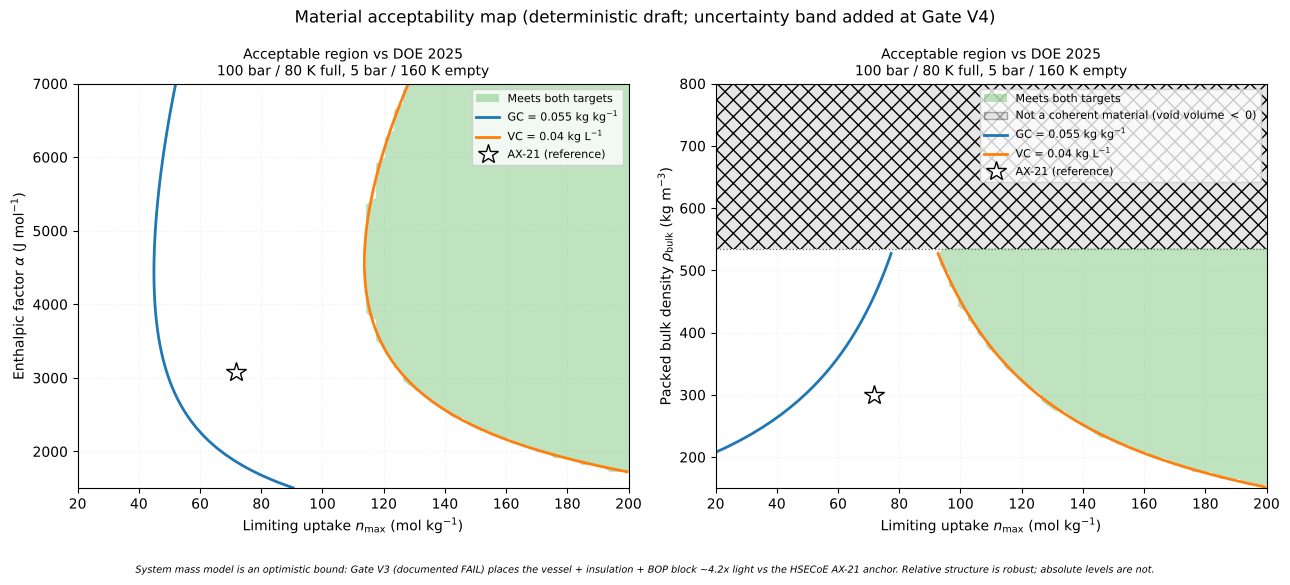

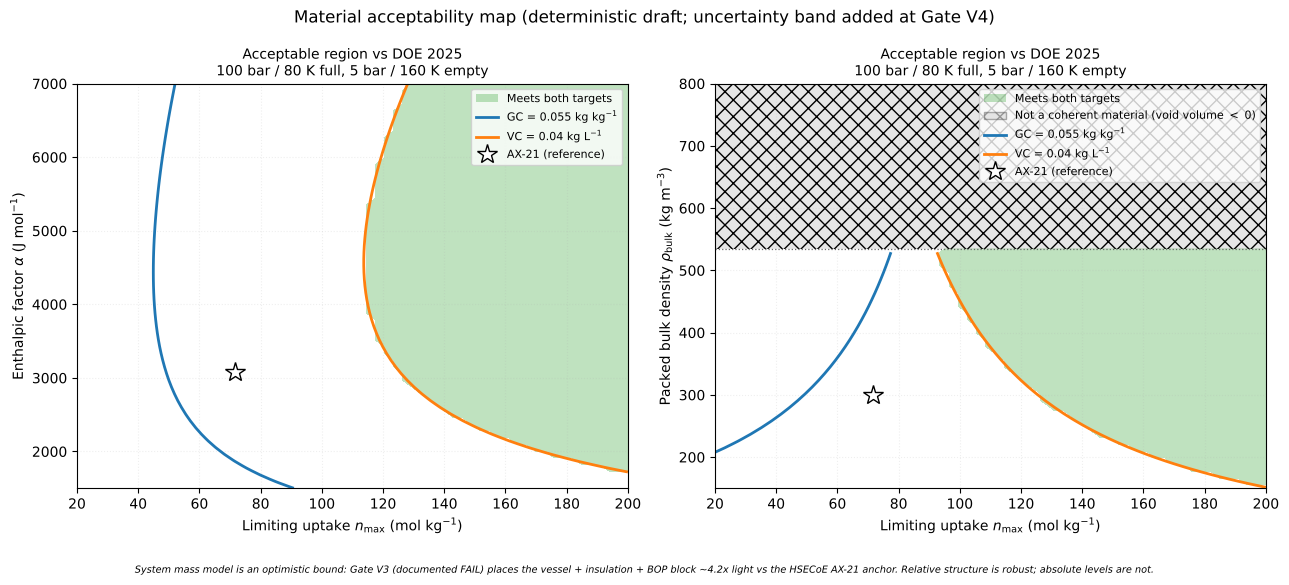

In [7]:
reference_points = {
    "AX-21 (reference)": {
        "n_max": material.n_max,
        "alpha": material.alpha,
        "rho_bulk": material.rho_bulk,
    },
}

fig, axes = plot_acceptability_maps(
    [map_alpha, map_rho],
    reference_points=reference_points,
)

fig

The interpretation of these maps, the limits on what they may claim, and the
uncertainty band that replaces the sharp boundary are written up in `docs/`. This
notebook reproduces the numbers and the figure only.